### Exploratory Data Analysis for Data Analysts in India

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
df = load_dataset('Lukebarousse/data_jobs')
df = df['train']
df = df.to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

#### Filtering for Data Analyst jobs in India

In [ ]:
df_IND = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

#### Top locations by number of job postings

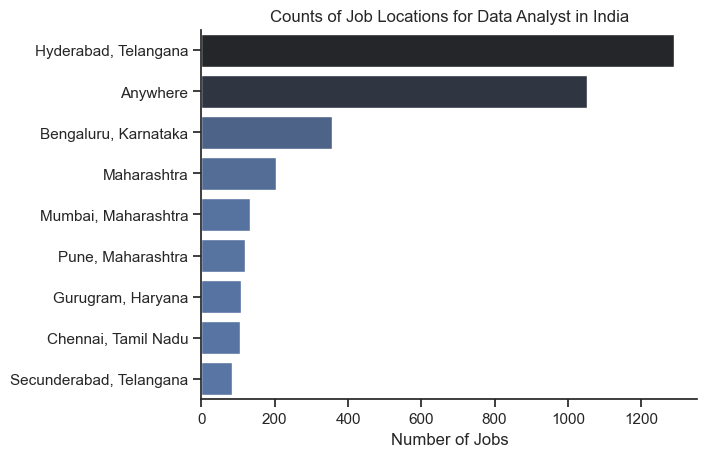

<Figure size 1000x600 with 0 Axes>

In [ ]:
#Count of job locations 
df_plot = df_IND['job_location'].value_counts().head(10).to_frame()

#Cleaning the Dataframe
df_plot.drop(axis=0, index='India', inplace=True)
df_plot.reset_index(inplace = True)
df_plot['job_location'] = [i.replace(', India', '') for i in df_plot.job_location]

#Creating a horizontal bar plot
sns.set_theme(style='ticks')
sns.barplot(df_plot, x='count', y='job_location', legend=False, hue='count', palette='dark:b_r')
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.figure(figsize=(10, 6))
plt.show()

#### Visualizing the columns with boolean values

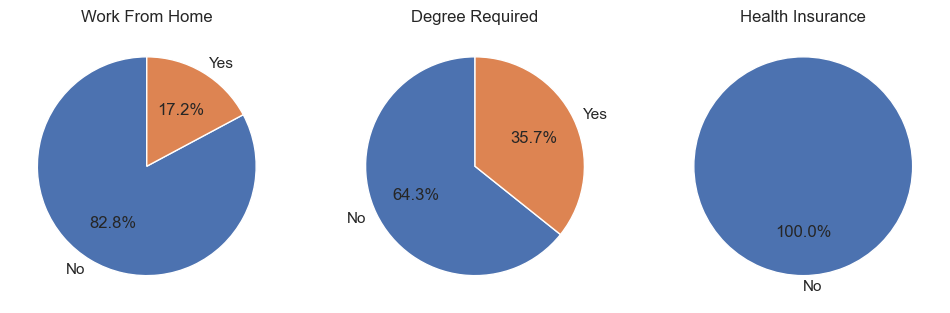

In [3]:
dict_titles = {
        'job_work_from_home' : 'Work From Home',
        'job_no_degree_mention' : 'Degree Required',
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))
for i, (column, title) in enumerate(dict_titles.items()):
    ax[i].pie(df_IND[column].value_counts(), labels=['No', 'Yes'],autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

ax[2].pie(df_IND['job_health_insurance'].value_counts(), autopct='%1.1f%%', startangle=90, labels=['No'])
ax[2].set_title('Health Insurance')
plt.show()

#### Top companies by number of job postings

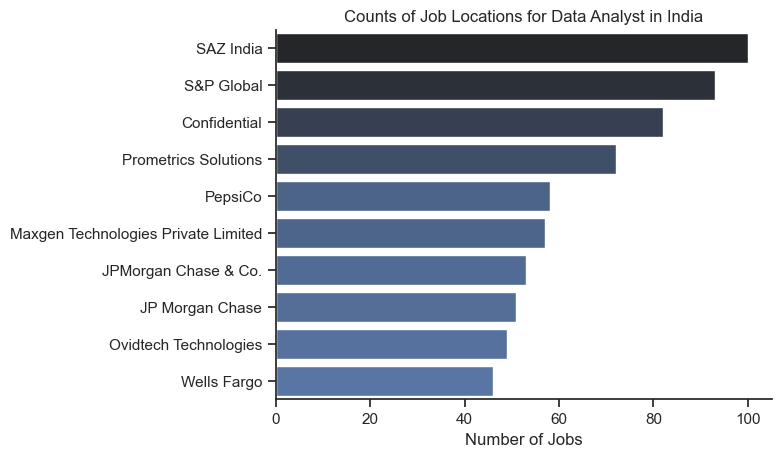

<Figure size 1000x600 with 0 Axes>

In [4]:
#Count of Company names
df_plot = df_IND['company_name'].value_counts().head(10).to_frame()

#Creating a horizontal bar plot
sns.set_theme(style='ticks')
sns.barplot(df_plot, x='count', y='company_name', legend=False, hue='count', palette='dark:b_r')
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.figure(figsize=(10, 6))
plt.show()